# Retail Sales Forecasting & Inventory Optimization

## Exploratory Data Analysis (EDA)

### Objective
The goal of this project is to analyze retail sales data and identify the factors affecting product sales. The insights gained from EDA will help in building machine learning models for sales prediction and inventory optimization.

### Dataset Information
The dataset contains retail sales records across multiple stores and products, including pricing, inventory, promotions, weather conditions, and demand-related features.

### Target Variable
- Units Sold

## Import Required Libraries

We import the libraries needed for:
- Data manipulation
- Visualization
- Statistical analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Plot Settings
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
# Load Dataset
df = pd.read_csv("retail_sales_enriched.csv")
df.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Date,Year,Quarter,Month,WeekOfYear,DayOfWeek
0,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,2022-01-01,2022,1,1,52,5
1,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,2022-01-01,2022,1,1,52,5
2,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,2022-01-01,2022,1,1,52,5
3,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,2022-01-01,2022,1,1,52,5
4,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,2022-01-01,2022,1,1,52,5


In [4]:
## Dataset Dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 73100
Columns: 20
<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Store ID            73100 non-null  str    
 1   Product ID          73100 non-null  str    
 2   Category            73100 non-null  str    
 3   Region              73100 non-null  str    
 4   Inventory Level     73100 non-null  int64  
 5   Units Sold          73100 non-null  int64  
 6   Units Ordered       73100 non-null  int64  
 7   Demand Forecast     73100 non-null  float64
 8   Price               73100 non-null  float64
 9   Discount            73100 non-null  int64  
 10  Weather Condition   73100 non-null  str    
 11  Holiday/Promotion   73100 non-null  int64  
 12  Competitor Pricing  73100 non-null  float64
 13  Seasonality         73100 non-null  str    
 14  Date                73100 non-null  str    
 15  Year                73100 non-null  int6

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Inventory Level,73100.0,274.469877,129.949514,50.00,162.00,273.000,387.0000,500.00
Units Sold,73100.0,136.464870,108.919406,0.00,49.00,107.000,203.0000,499.00
Units Ordered,73100.0,110.004473,52.277448,20.00,65.00,110.000,155.0000,200.00
Demand Forecast,73100.0,141.494720,109.254076,-9.99,53.67,113.015,208.0525,518.55
Price,73100.0,55.135108,26.021945,10.00,32.65,55.050,77.8600,100.00
Discount,73100.0,10.009508,7.083746,0.00,5.00,10.000,15.0000,20.00
Holiday/Promotion,73100.0,0.497305,0.499996,0.00,0.00,0.000,1.0000,1.00
Competitor Pricing,73100.0,55.146077,26.191408,5.03,32.68,55.010,77.8200,104.94
Year,73100.0,2022.502052,0.502728,2022.00,2022.00,2023.000,2023.0000,2024.00
Quarter,73100.0,2.507524,1.117404,1.00,2.00,3.000,4.0000,4.00


In [6]:
#Missing Value Analysis
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [7]:
#Duplicate Record Analysis
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


## Distribution of Units Sold

Understanding the distribution of the target variable.

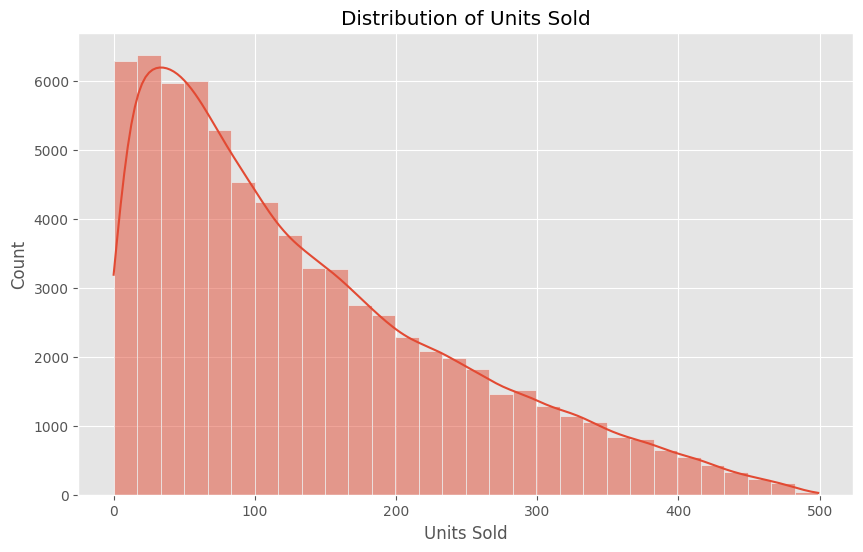

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Units Sold"],
    bins=30,
    kde=True
)

plt.title("Distribution of Units Sold")
plt.show()

### Observation

Analyze whether the sales distribution is:
- Normal
- Right Skewed
- Left Skewed
- Contains Outliers

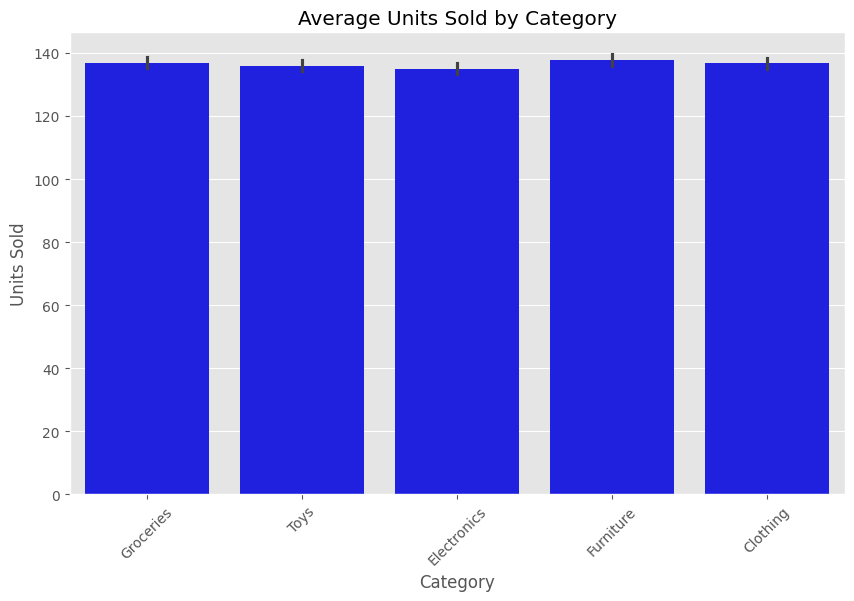

In [10]:
# Category-wise Sales Analysis
plt.figure(figsize=(10,6))

sns.barplot(
    x="Category",
    y="Units Sold",
    color='blue',
    data=df
)

plt.title("Average Units Sold by Category")
plt.xticks(rotation=45)

plt.show()

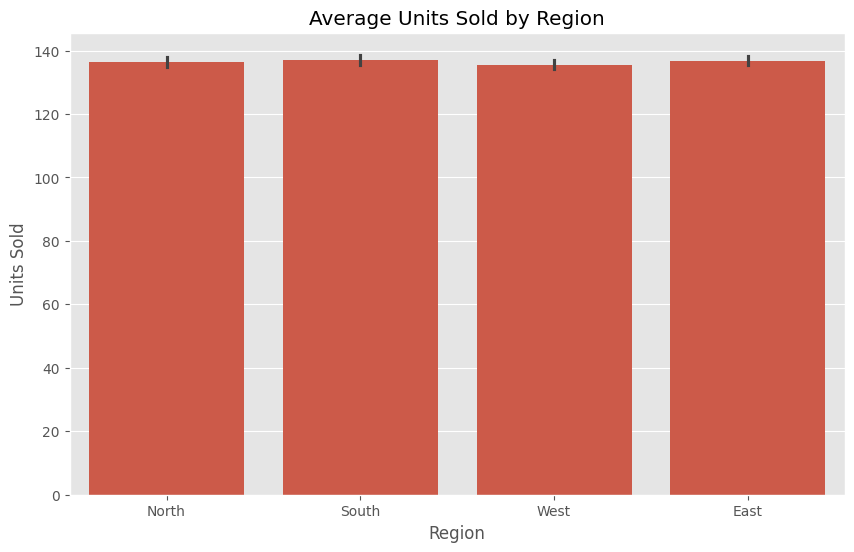

In [11]:
# Regional Sales Analysis
plt.figure(figsize=(10,6))

sns.barplot(
    x="Region",
    y="Units Sold",
    data=df
)

plt.title("Average Units Sold by Region")
plt.show()

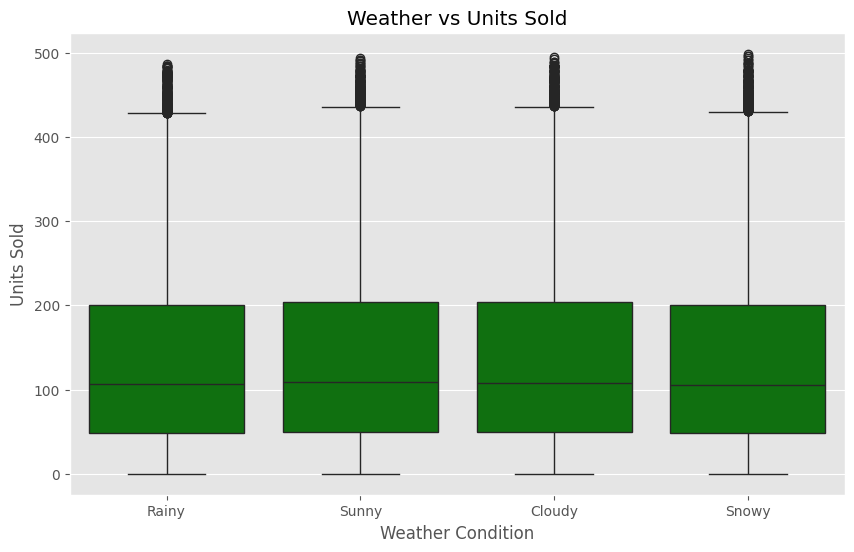

In [12]:
# Impact of Weather on Sales
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Weather Condition",
    y="Units Sold",
    color='green',
    data=df
)

plt.title("Weather vs Units Sold")
plt.show()

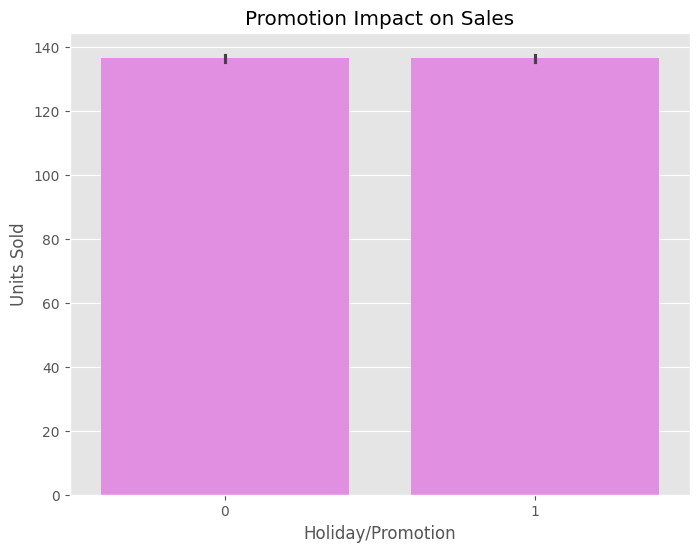

In [14]:
# Promotion Impact Analysis
plt.figure(figsize=(8,6))

sns.barplot(
    x="Holiday/Promotion",
    y="Units Sold",
    color='violet',
    data=df
)

plt.title("Promotion Impact on Sales")
plt.show()

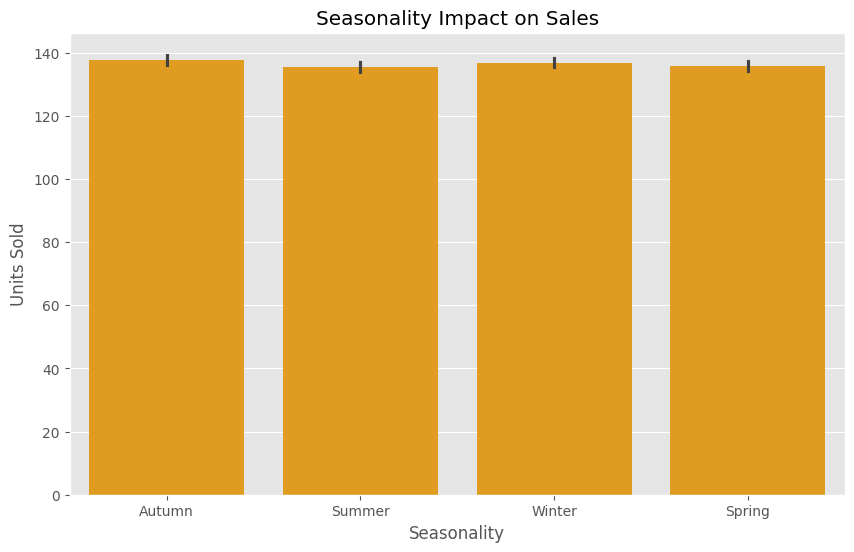

In [15]:
# Seasonal Sales Analysis
plt.figure(figsize=(10,6))

sns.barplot(
    x="Seasonality",
    y="Units Sold",
    color='orange',
    data=df
)

plt.title("Seasonality Impact on Sales")
plt.show()

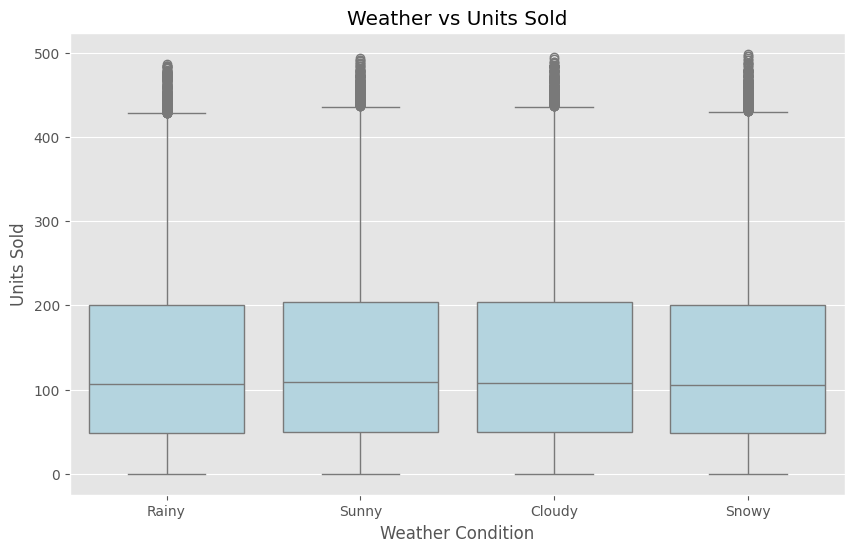

In [16]:
# Impact of Weather on Sales
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Weather Condition",
    y="Units Sold",
    color='lightblue',
    data=df
)

plt.title("Weather vs Units Sold")
plt.show()

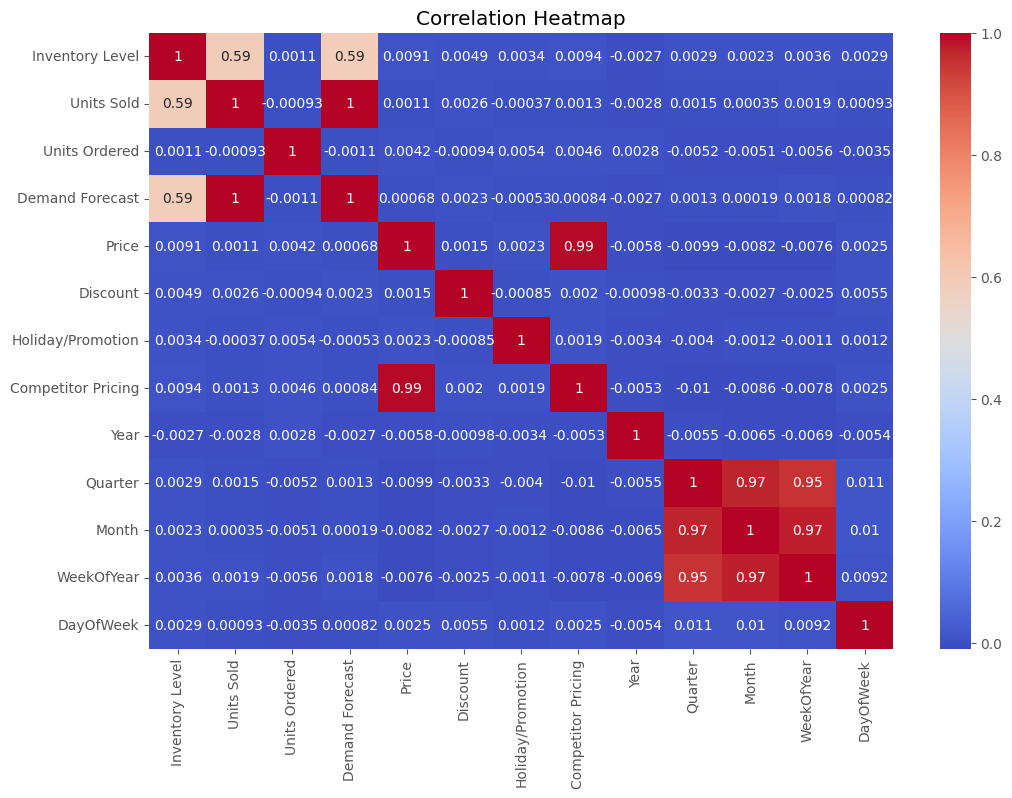

In [17]:
# Correlation Analysis
numerical_cols = df.select_dtypes(
    include=["int64","float64"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numerical_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

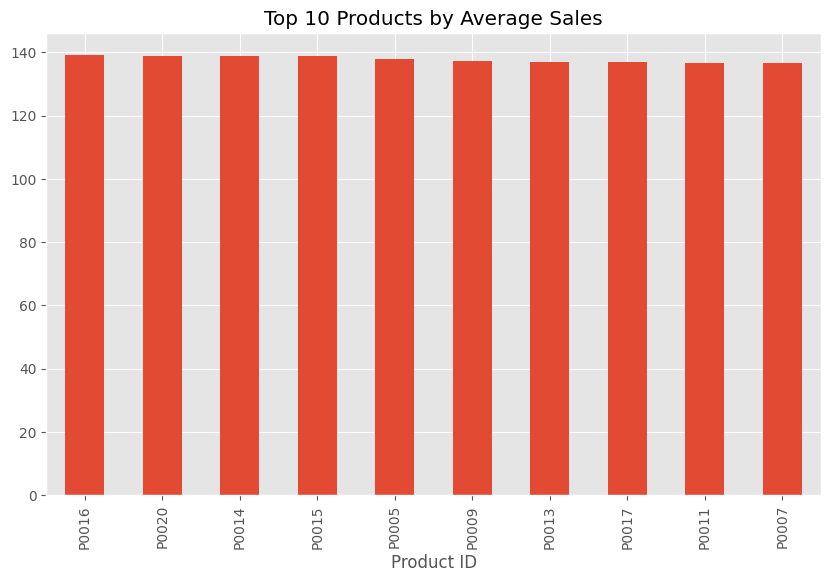

In [18]:
## Top Selling Products
top_products = (
    df.groupby("Product ID")["Units Sold"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top 10 Products by Average Sales")
plt.show()

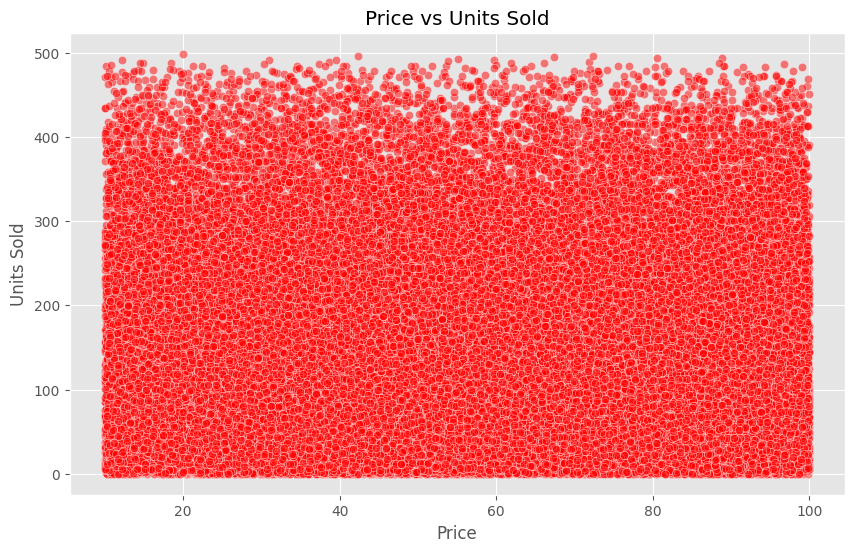

In [20]:
# Price vs Sales Relationship
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Price",
    y="Units Sold",
    data=df,
    color='red',
    alpha=0.5
)

plt.title("Price vs Units Sold")
plt.show()

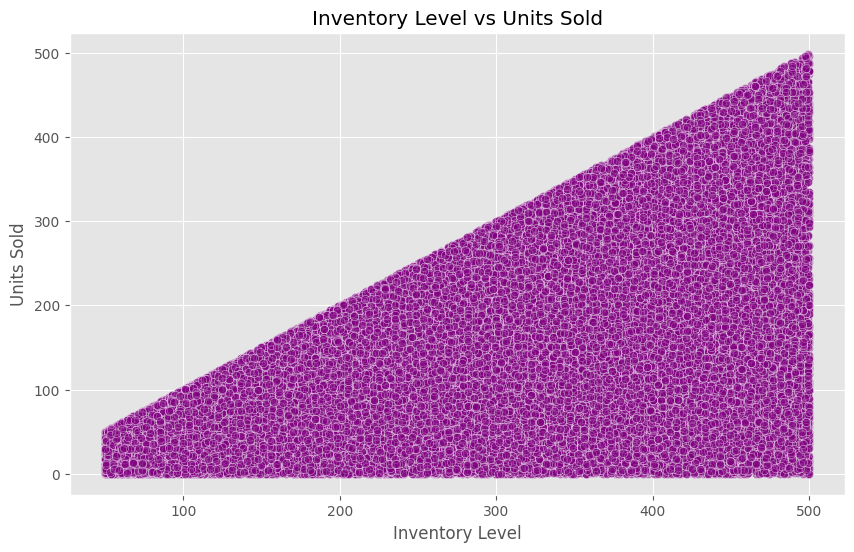

In [22]:
## Inventory Level vs Sales
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Inventory Level",
    y="Units Sold",
    color='purple',
    data=df,
    alpha=0.5
)

plt.title("Inventory Level vs Units Sold")
plt.show()

# EDA Summary

## Key Findings

1. Sales distribution analysis completed.
2. Category-wise sales trends identified.
3. Regional performance differences observed.
4. Weather conditions influence sales behavior.
5. Promotions impact customer demand.
6. Seasonality affects purchasing patterns.
7. Pricing and inventory levels show measurable relationships with sales.

## Next Steps

- Data Preprocessing
- Feature Encoding
- Train-Test Split
- Model Comparison
- Hyperparameter Tuning
- Explainable AI (SHAP)